# Research Note


**MTS Formation**:
\begin{aligned}
    X_{MTS} = [N_{T}, N_{F}] =\begin{bmatrix}
                                X_1 \\
                                X_2 \\
                                \vdots \\
                                X_T
                            \end{bmatrix} = \begin{bmatrix}
                                x_{11} && x_{12} & x_{13} & \dots & x_{1F} \\
                                x_{21} && x_{21} & x_{13} & \dots & x_{2F} \\
                                \vdots && \vdots & \vdots & \ddots & \vdots \\
                                x_{T1} && x_{T2} & x_{T3} & \dots & x_{TF} \\
                            \end{bmatrix}\\
    \\
    X_{windows} = \begin{bmatrix}
        w_1 \\
        w_2 \\
        \vdots \\
        w_T
    \end{bmatrix} = \begin{bmatrix}
        [X_1 && X_2 && \dots && X_L]\\
        [X_2 && X_3 && \dots && X_{L+1}]\\
        [X_3 && X_4 && \dots && X_{L+2}]\\
        \vdots && \vdots && \ddots && \vdots \\
        [X_{T-L} && X_{T-L+1} && \dots && X_T]\\
    \end{bmatrix} = \begin{bmatrix}
        \begin{bmatrix}
                    x_{11} && x_{12} & x_{13} & \dots & x_{1F} \\
                    \vdots && \vdots & \vdots & \ddots & \vdots \\
                    x_{L1} && x_{L2} & x_{L3} & \dots & x_{LF} \\
        \end{bmatrix}\\
        \begin{bmatrix}
                    x_{21} && x_{22} & x_{23} & \dots & x_{2F} \\
                    \vdots && \vdots & \vdots & \ddots & \vdots \\
                    x_{[L+1]1} && x_{[L+1]2} & x_{[L+1]3} & \dots & x_{[L+1]F} \\
        \end{bmatrix} \\
        \vdots \\
        \begin{bmatrix}
                    x_{[T-L]1} && x_{[T-L]2} & x_{[T-L]3} & \dots & x_{[T-L]F} \\
                    \vdots && \vdots & \vdots & \ddots & \vdots \\
                    x_{[T]1} && x_{[T]2} & x_{[T]3} & \dots & x_{[T]F} \\
        \end{bmatrix} \\
    \end{bmatrix}
\end{aligned}

tf.signal.frame(tf.convert_to_tensor(X_train_full, dtype=tf.float32), frame_length=5, frame_step=1, axis=0) = Shape([N, L, F])
- Correctly performs the sliding windows formation, at the timestep level ==> Correctly form X_windows (a tensor of sliding windows)



# Classification Loss on synthetic anomaly

Check corruption strength, may be too trivial that LSTM mask it out ~ Valid --> Corruption strength affect triviality
- Seems like bias is the only thing working for LSTM / temporal perturbing doesnt work unless affecting the full window
- If bias is too strong, the classification learning becomes trivial, and hard to perform on test data

For industrial timeseries dataset:
- Could assume that all sensors operational data tends to be in its normal state, so ideally corruption occurs when a sensor fails / drifts
- Biasing creates 'most realistic' anomaly, or reversal of series, or force constants

# Encoder:
LSTM-based encoder model that extracts temporal representations from sequential data and projects them into a latent embedding space
    This encoder consists of:
        - A stack of LSTM layers (configurable number of layers and units)
        - A projection head (Dense → BatchNorm → ReLU → Dense)
        - L2 normalization applied to the final latent vector

Research topics: 
- Anomaly score assigned to last timestep of the window
- Corruptor does corrupt correctly
- Inject non-trivial anomalies such that it deteriorates baseline models detections

Variational Autoencoder:
- Probabilistic Generative Model + amortized variational inference procedures
- Assumes every datapoint `x` is GENERATED FROM low-dimensional latent variable `z` through a generative process $p_\theta(x|z)$, we put a simple prior on z $\mathcal{N}(0,I)$. Trains 2 neural nets:
  1.  Encoder $q_\phi(z|x)$ infers the intractable true posterior $p_\theta(z|x)$. Outputs a distribution per sample. Sample's encoding is drawn for that Gaussian
  2.  Decoder $p_\theta(x|z)$ maps the latent z back to original data space

- Why per-sample?
  - Encoder outputs $\mu_i$ and $\sigma_i^2$ for a sample $x_i$
    - $\mu_i$ is the center, or 'most-likely' latent representation for $x_i$. The encoder's best determinisitic guess for where $x_i$ should live in latent space
    - $\sigma_i$ is the uncertainty - how much z may vary while still producing similar x. Encoder's confidence in the current guess
  - Model z for that sample as a full distribution $q_\phi(z|x_i) = \mathcal{N}(z; \mu_i, diag(\sigma^2_i))$. VAE trains to the per-sample distributions both reconstruct well, and remain close to the prior
    - z becomes an output of a 'deterministic' function of $\mu$ and $\sigma$ and a noise variable $\epsilon$ independent of $\phi$
- In additionally, use closed-form KL for Gaussian q and standard normal prior, which pulls $\mu_j$ toward 0, and $\sigma_j^2$ toward 1
  - KL term also prevents encoder from putting arbitrary $\mu_i$ and tiny $\sigma_i$ for every sample

- Inference: VAE can be used for
  - Reconstruction
  - New data generation
    1. Sample from the prior $z ~ p(z) = \mathcal(0, I)$
    2. Decode $x ~ p_\theta(x|z)$, or take decode rmean to get a generated sample $\hat{x}$

**Non-trivial Anomaly Injection**: Pretrain injection
1. GenIAS:
   - Differ from other injection methodology, by working in the `latent space`, while ensuring contamination-tolerant and realistic anomaly generation that are distinct from normal data, while maintaining plausibility
     - Encoder (TCN-VAE) -> Latent Space ($\mu$, $\sigma^2$) -> Decoder
     - Normal sample is sampled from $\mathcal{N}(\mu, \sigma^2)$
     - **Anomalous $\tilde{z}$ is obtained by perturbing** the standard deviation $\sigma$ while keeping $\mu$ unchanged. Maintains the realism of the generated anomaly
       - $\tilde{z} = \mu + \psi(\sigma \odot \epsilon) $, where $\odot$ denotes Element-wise Hadamard product, $\psi$ denotes the learned perturbation scale, and $\epsilon$ a noise vector sampled from $\mathcal{N}(0, 1)$
       - Decoding $\tilde{z}$ produces the anomalous $\tilde{x}$
     - Generated preliminary anomaly $\tilde{X}$, deviation-based patch is applied, by applying a deviation threshold $\tau$ to ensure generated smaples are realistic, and aligned with domain requirements
   - Training Loss Function:
     - $\mathcal{L} = \alpha \cdot \mathcal{L}_{MSE}(X, \hat{X}) + \beta \cdot \mathcal{L}_{perturb} + \gamma \cdot \mathcal{L}_{zero-perturb} + \zeta \cdot \mathcal{L}_{en-KL}$ where:
         1.  $\mathcal{L}_{MSE}(X, \hat{X})$ : Reconstruction loss between normal X and $\hat{X}$, ensuring temporal and structural patterns are learned  \\
            \begin{align}
                    \frac{1}{|\mathcal{D}|} \sum_{X\in \mathcal{D}} \frac{1}{T \cdot \mathcal{D}} \sum^T_{t=1}\sum^\mathcal{D}_{d=1} (X[t,d] - \hat{X}[t, d])^2
            \end{align}
         2.  $\mathcal{L}_{perturb}(X.{\tilde{X}})$ : Designed to ensure generated anomalies $\tilde{X}$ are both distinct from $X$ and realistic   
             -  Distinctness: Enforces minimum margin $\delta_{min}$ between $d(X, \hat{X})$ and $d(X, \tilde{X})$, pushes anomalies away from normal samples in raw time-series
             -  Realism: Regularization term that penalizes deviations when distance $d(X, \tilde{X})$ exceeds a threshold $\delta_{max}$, ensuring anomalies remain plausible 
             -  Denote $d$ as MSE distance
            \begin{align}
                    \frac{1}{|\mathcal{D}|} \sum_{X \in \mathcal{D}} [max(d(X, \hat{X}) - d(X, \tilde{X}) + \delta_{min}, 0)] 
                    + \frac{1}{|\mathcal{D}|} \sum_{X \in \mathcal{D}} max(d(X, \tilde{X}) - \delta_{max}, 0)
            \end{align}
         3. $\mathcal{L}_{zero-perturb}(\tilde{X})$ : Encourages the generated anomaly $\tilde{X}$ to introduce meaningful perturbation in dimensions of input sample that are entirely zeros, perserving the unique characteristics of those dimension  \\
        \begin{align}
            \frac{1}{|\mathcal{D}|} \sum_{X \in \mathcal{D}} (\frac{1}{T \cdot |\mathcal{Z}|}\sum_{t=1}^T \sum_{d\in\mathcal{Z}}(d(X, \tilde{X})+1)^{-1})
        \end{align}
            - Where $\mathcal{Z}$ is the set of zero-valued dimension in X. By penalizing dimensions that deviate unrealistically in regions of zero value, this loss encourages the model to generate plausible anomalies 
         4. $\mathcal{L}_{en-KL}(\tilde{X})$: Enhanced KL Divergence Loss, modifies the standard VAE regularization term by incorporating a tunable prior variances ($\sigma^2_{prior} < 1$). Enforces tighter, more compact clustering of normal samples in latent space. Enhances separation between normal and anomalous data when perturbation is applied. 
        \begin{align}
            -\frac{1}{2} \sum_{i=1}^{|\mathcal{D}|} \sum_{j=1}^L [1+log(\sigma^2_{ij}) - \mu_{ij}^2 - \frac{\sigma_{ij}^2}{\sigma_{prior}^2} + 2log(\sigma_{prior})]
        \end{align}
            - Where $\mu_{ij}$ and $\sigma_{ij}^2$ are the mean and variance of the latent distribution for the j-th dimension of the i-th sample, and $\sigma_{prior}$ is the prior's standard deviation 

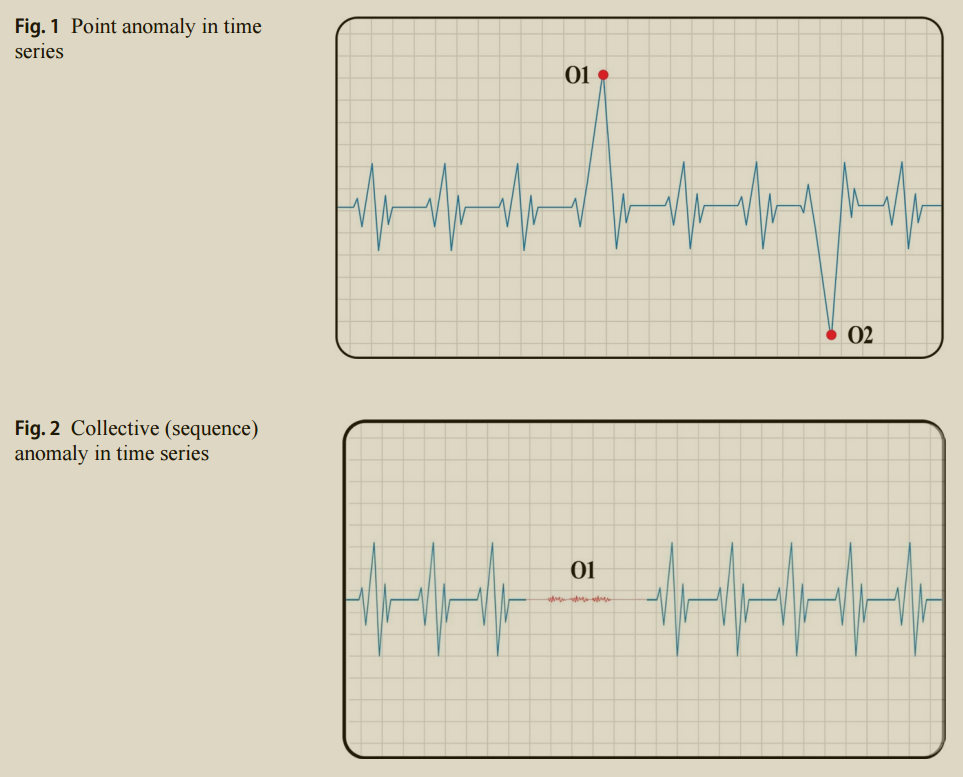

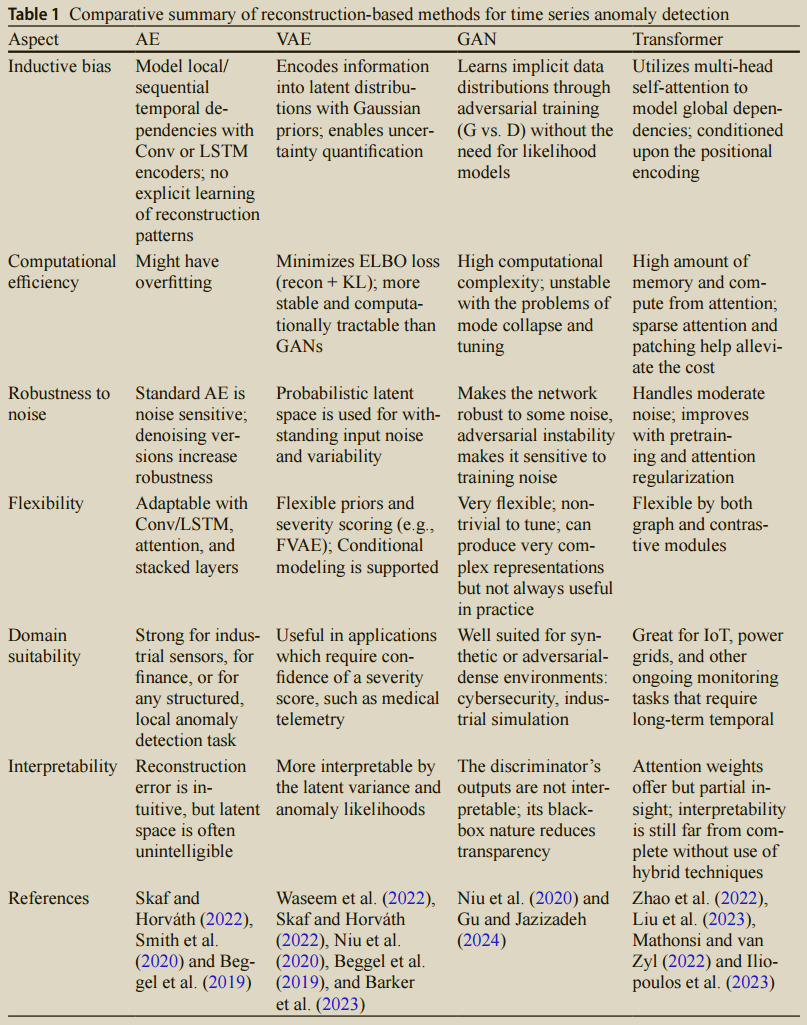